In [1]:
# Install required packages
%pip install -qq netcdf4 xarray harmony-py python-cmr geopandas wget
%pip install -qq pandas xarray matplotlib netcdf4 pyproj pyrsig pycno thefuzz geopandas
%pip install git+https://github.com/barronh/pyrsig.git

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/barronh/pyrsig.git to /tmp/pip-req-build-7xv28rfm
  Running command git clone --filter=blob:none --quiet https://github.com/barronh/pyrsig.git /tmp/pip-req-build-7xv28rfm
  Resolved https://github.com/barronh/pyrsig.git to commit a748195bc38f4566893634a5e010308f4ca8b97f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load packages into current runtime
import datetime as dt
import geopandas as gpd

import wget
import os

# Import Libraries
import pyrsig
import pandas as pd
import pycno
import getpass
import matplotlib.pyplot as plt
from collections import defaultdict
import re
from thefuzz import process, fuzz

In [3]:
# Get United States urban areas shapefile
# This is written to be used on a linux machine, might not work on mac
if(not os.path.isdir("city_shapefile")):
    os.makedirs("city_shapefile")
    wget.download("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_ua10_500k.zip", out="./city_shapefile")
    !unzip city_shapefile/* -d ./city_shapefile
    !rm city_shapefile/*.zip

gdf_cities = gpd.read_file("city_shapefile/")

#  Verify the cities were loaded correctly
city_names = gdf_cities['NAME10']

print(gdf_cities.head())


  UACE10      AFFGEOID10 GEOID10              NAME10 LSAD10 UATYP10  \
0  88732  400C100US88732   88732          Tucson, AZ     75       U   
1  01819  400C100US01819   01819         Alturas, CA     76       C   
2  22366  400C100US22366   22366   Davenport, IA--IL     75       U   
3  93322  400C100US93322   93322  Waynesboro, PA--MD     76       C   
4  02548  400C100US02548   02548          Angola, IN     76       C   

     ALAND10  AWATER10                                           geometry  
0  915276150   2078695  MULTIPOLYGON (((-110.81345 32.1191, -110.79879...  
1    4933312     16517  MULTIPOLYGON (((-120.5461 41.51264, -120.54594...  
2  357345121  21444164  MULTIPOLYGON (((-90.36678 41.53636, -90.36462 ...  
3   45455957     88872  MULTIPOLYGON (((-77.50746 39.71577, -77.50605 ...  
4   23646957   3913803  MULTIPOLYGON (((-85.01158 41.593, -85.00589 41...  


In [4]:
# Populates a dictionary that converts a states two-letter post code into a fips code
postal_to_fips = dict()
with open("fips.txt", "r") as file:
    for line in file:
        # Uses list comprehension to only get the entries that are 2 uppercase letters
        line = [s for s in re.split("\t| ", line[:-1]) if len(s) == 2 and s.upper() == s]
        postal_to_fips[line[0]] = line[1]

print(postal_to_fips)

{'AL': '01', 'NE': '31', 'AK': '02', 'NV': '32', 'AZ': '04', 'NH': '33', 'AR': '05', 'NJ': '34', 'CA': '06', 'NM': '35', 'CO': '08', 'NY': '36', 'CT': '09', 'NC': '37', 'DE': '10', 'ND': '38', 'DC': '11', 'OH': '39', 'FL': '12', 'OK': '40', 'GA': '13', 'OR': '41', 'HI': '15', 'PA': '42', 'ID': '16', 'PR': '72', 'IL': '17', 'RI': '44', 'IN': '18', 'SC': '45', 'IA': '19', 'SD': '46', 'KS': '20', 'TN': '47', 'KY': '21', 'TX': '48', 'LA': '22', 'UT': '49', 'ME': '23', 'VT': '50', 'MD': '24', 'VA': '51', 'MA': '25', 'VI': '78', 'MI': '26', 'WA': '53', 'MN': '27', 'WV': '54', 'MS': '28', 'WI': '55', 'MO': '29', 'WY': '56', 'MT': '30'}


In [5]:
# Uses fuzzy pattern matching to try to best approximate the city the user wants to laod
# Works pretty well, but some cities are annoying syntactically
# (e.g "washington dc" outputs "washington nc," you have to put "washington d.c")
def get_best_match(cityString: str, stateString: str) -> str:
    min_match = 60
    # ensure that the first letter of the string is uppercase, and the rest is lowercase
    cityString = cityString[0].upper() + cityString[1:].lower()
    collection = defaultdict(list)
    # Create a dictionary of the form "City -> list of all state with a city of that name"
    for s in city_names:
        collection[s.split(",")[0]].append(s.split(",")[1][1:])

    # Use the TheFuzz library to get the closest city match
    results = process.extract(cityString, collection.keys(), scorer=fuzz.token_sort_ratio, limit=10)

    if results[0][1] < min_match:
        # If none of the results are strong enough, return none
        return None
    
    if len(collection[results[0][0]]) > 1:
        # If there is more than one state matches, remove the city name and check the match again
        state = process.extract(stateString, collection[results[0][0]], scorer=fuzz.token_sort_ratio, limit=1)
        if state[0][1] < 40:
            print("Please specify the state and try again! Remember to use the states 2-letter postal code (i.e New York is NY)")
        else:
            return(f"{results[0][0]}, {state[0][0]}")
    else:
        # If there's only city (e.g Hartford, CT is the only Hartford) just return that city
        return (f"{results[0][0]}, {collection[results[0][0]][0]}")

city_name = get_best_match("Hartford", "CT")
print(city_name)

Hartford, CT


/home/april_loy/.venv/lib/python3.10/site-packages/geopandas/geodataframe.py:2675: UserWarning: `keep_geom_type=True` in overlay resulted in 176 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  return geopandas.overlay(


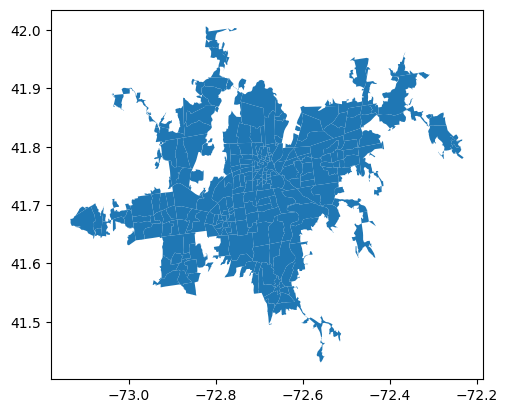

In [13]:
if not os.path.isdir("tracts_shapefile"):
    os.makedirs("tracts_shapefile")

# Cities that cross multiple state lines are seperated by multiple dashes
# e.g Seattle OR--WA
state = city_name.split(", ")[1]
census_tracts = gpd.GeoDataFrame()
for s in state.split("--"):
    # For each state in the city, extract the fips code (a two-digit number used to identify each US state and territory)
    fips_code = postal_to_fips[s]
    # Use string formatting to automatically download census tract shapefiles for each relevant state
    if not os.path.isdir(f"tracts_shapefile/{s}"):
        os.makedirs(f"tracts_shapefile/{s}")
        wget.download(f"https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_{fips_code}_tract_500k.zip", out=f"./tracts_shapefile/{s}")
    if census_tracts.empty:
        census_tracts = gpd.read_file(f"./tracts_shapefile/{s}/cb_2018_{fips_code}_tract_500k.zip")
    else:
        new_tracts = gpd.read_file(f"./tracts_shapefile/{s}/cb_2018_{fips_code}_tract_500k.zip")
        census_tracts = pd.concat([census_tracts, new_tracts])

# Extract the shapefile for the urban area from the earlier shapefile
city = gdf_cities[gdf_cities["NAME10"] == city_name]
# Get the intersection of the census tracts shapefile and the urban area shapefile
intersection = census_tracts.overlay(city, how="intersection")
f, ax = plt.subplots()
# Plot the intersection
intersection.plot(ax=ax)    
os.makedirs(city_name, exist_ok=True)
os.makedirs(f"{city_name}/tracts", exist_ok=True)
intersection.to_file(f"{city_name}/tracts/city_with_tracts.shp")

In [7]:
# bbox = city.bounds

# bbox = bbox.values[0]
# bbox
# center_lat = ((bbox[0] + bbox[2]) / 2)
# start_time = 11
# start_time += center_lat / 15
# start_minute = ((start_time % 1) * 60) // 1
# #start_minute = ((start_time % 1) * 60)
# start_hour = start_time // 1
# end_hour = start_hour+3

# start = pd.to_datetime('04/04/25 ' + str(start_hour) + ':' + str(start_minute))
# end = pd.to_datetime('04/04/25 ' + str(end_hour) + ':' + str(start_minute))

# #start += pd.Timedelta(days=90)
# start < end

In [8]:
products = ['tempo.l2.no2.vertical_column_troposphere', 'tempo.l2.hcho.vertical_column']
city = gdf_cities[gdf_cities["NAME10"] == city_name]
# Get the bounding box of the urban area
bbox = city.bounds

bbox = bbox.values[0]

bbox = city.bounds

bbox = bbox.values[0]
bbox
center_x = ((bbox[0] + bbox[2]) / 2)
start_time = 11
start_time -= center_x / 15
start_minute = ((start_time % 1) * 60) // 1
start_hour = start_time // 1
end_hour = start_hour+3

# Compare over various seasons
start1day = pd.to_datetime('09/01/24 ' + str(start_hour) + ':' + str(start_minute), utc=True)
end1day = pd.to_datetime('09/01/24 ' + str(end_hour) + ':' + str(start_minute), utc=True)

endrange = end1day + pd.Timedelta(days=1)
os.makedirs(f"{city_name}/TEMPO", exist_ok=True)

total = 0
errors = 0
while (start1day < endrange):
    # Download the TEMPO data from the selected dates, over the selected area
    # Need to use overwrite = true because the tempo api will re-use files with incomplete data
    total += 2
    print(start1day.tzinfo)
    print(end1day)
    api = pyrsig.RsigApi(bdate=start1day, edate=end1day, bbox=bbox, overwrite = True, workdir=f"{city_name}/TEMPO")
    api_key = 'anonymous'  # using public data, so using anonymous TODO: Determine limits of public data
    api.tempo_kw['api_key'] = api_key
    # Convert to a data frame
    for product in products:
        try:
            api.to_netcdf(product, removegz=True)
        except:
            errors += 1
            pass

    
    start1day += pd.Timedelta(days=1)
    end1day += pd.Timedelta(days=1)


print("error rate: ", errors / total)

UTC
2024-09-01 18:50:00+00:00
UTC
2024-09-02 18:50:00+00:00
error rate:  0.0


In [10]:
# Convert the netcdf files to rdata
os.system(f"Rscript make_rdata.r \"{city_name}\"")

Loading required package: sp


0

In [12]:
# Fetch census data for the given city
os.system(f"Rscript census_data.r \"{city_name}\"")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Linking to GEOS 3.11.1, GDAL 3.6.4, PROJ 9.1.1; sf_use_s2() is TRUE
Loading required package: viridisLite
To install your API key for use in future sessions, run this function with `install = TRUE`.
Getting data from the 2019-2023 5-year ACS


Writing layer `demographics' to data source 
  `Hartford, CT/demographics_shapefile/demographics.shp' using driver `ESRI Shapefile'
Writing 262 features with 20 fields and geometry type Multi Polygon.


There were 50 or more warnings (use warnings() to see the first 50)
Saving 7 x 7 in image
Saving 7 x 7 in image


0

In [ ]:
# Turn the pollution data into simple features objects
os.system(f"Rscript process_pollution_data.r \"{city_name}\"")

Linking to GEOS 3.11.1, GDAL 3.6.4, PROJ 9.1.1; sf_use_s2() is TRUE
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: sp

Attaching package: ‘raster’

The following object is masked from ‘package:dplyr’:

    select

Loading required package: abind
Loading required package: viridisLite

Attaching package: ‘viridis’

The following object is masked from ‘package:scales’:

    viridis_pal



[1] "loading files"
[1] "all files loaded"
[1] "starting merge"
[1] "merge finished"
[1] "starting intersection... this could take a while"
[1] "intersection finished"
Writing layer `pollution' to data source 
  `Buffalo, NY/pollution_shapefile/pollution.shp' using driver `ESRI Shapefile'
Writing 263 features with 20 fields and geometry type Multi Polygon.


There were 50 or more warnings (use warnings() to see the first 50)
Saving 7 x 7 in image
Saving 7 x 7 in image
Saving 7 x 7 in image


0

In [ ]:
# Combine the pollution data and the demographic data 
os.system(f"Rscript combine_data.r \"{city_name}\"") 

Linking to GEOS 3.11.1, GDAL 3.6.4, PROJ 9.1.1; sf_use_s2() is TRUE
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: sp

Attaching package: ‘raster’

The following object is masked from ‘package:dplyr’:

    select

Loading required package: viridisLite
Warning message:
attribute variables are assumed to be spatially constant throughout all geometries 
Saving 7 x 7 in image
Warning messages:
1: Removed 32 rows containing missing values or values outside the scale range
(`geom_point()`). 
2: Rem

0